In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import time


# -----------------------------
# Utilities
# -----------------------------

def random_unit(dim,n=1):
    v=np.random.randn(n,dim)
    v/=np.linalg.norm(v,axis=1,keepdims=True)
    return v if n>1 else v[0]


def normalized_error(d_est,d_true):
    return abs(d_est-d_true)/(d_true+1e-8)


# -----------------------------
# Manifold
# -----------------------------

class RadialManifold:

    def __init__(self,dim=256,complexity=2):

        self.dim=dim
        self.R0=1.0

        levels={
            0:(0,0),
            1:(4,0.05),
            2:(8,0.10),
            3:(12,0.15)
        }

        dents,amp=levels[complexity]

        self.num_dents=dents
        self.amp=amp

        if dents>0:
            c=np.random.randn(dents,dim)
            self.centers=c/np.linalg.norm(c,axis=1,keepdims=True)
        else:
            self.centers=None

        self.width=0.15
        self.width2=self.width**2


    def radius(self,theta):

        if self.num_dents==0:
            return self.R0

        dots=self.centers@theta
        ang2=2*(1-dots)

        dents=self.amp*np.exp(-ang2/(2*self.width2))

        return self.R0-np.sum(dents)


    def radius_batch(self,thetas):

        if self.num_dents==0:
            return np.ones(len(thetas))*self.R0

        dots=thetas@self.centers.T
        ang2=2*(1-dots)

        dents=self.amp*np.exp(-ang2/(2*self.width2))

        return self.R0-np.sum(dents,axis=1)


    def surface(self,theta):
        return self.radius(theta)*theta


# -----------------------------
# Target generation
# -----------------------------

def generate_targets(manifold,n=20,dist=0.3):

    targets=[]

    for _ in range(n):

        theta=random_unit(manifold.dim)
        surf=manifold.surface(theta)

        targets.append(surf+dist*theta)

    return np.array(targets)


# -----------------------------
# Ground truth
# -----------------------------

def ground_truth(manifold,target,restarts=6):

    dim=manifold.dim
    best=np.inf

    for _ in range(restarts):

        t0=random_unit(dim)

        def f(theta):

            theta=theta/np.linalg.norm(theta)
            x=manifold.surface(theta)

            return np.linalg.norm(x-target)

        res=minimize(
            f,
            t0,
            method="SLSQP",
            constraints={"type":"eq","fun":lambda t:np.linalg.norm(t)-1},
            options={"maxiter":120}
        )

        if res.fun<best:
            best=res.fun

    return best


# -----------------------------
# Methods
# -----------------------------

def method1(manifold,target,steps=40):

    theta=random_unit(manifold.dim)

    for _ in range(steps):

        x=manifold.surface(theta)

        grad=2*(x-target)

        theta-=0.05*grad
        theta/=np.linalg.norm(theta)

    return np.linalg.norm(manifold.surface(theta)-target)


def method2(manifold,target,rays=200):

    dirs=random_unit(manifold.dim,rays)

    r=manifold.radius_batch(dirs)
    surf=dirs*r[:,None]

    dists=np.linalg.norm(surf-target,axis=1)

    return np.min(dists)


def method3(manifold,target,K=40,steps=20):

    theta=random_unit(manifold.dim)

    for _ in range(steps):

        cand=theta+0.2*random_unit(manifold.dim,K)
        cand/=np.linalg.norm(cand,axis=1,keepdims=True)

        r=manifold.radius_batch(cand)
        surf=cand*r[:,None]

        d=np.linalg.norm(surf-target,axis=1)

        theta=cand[np.argmin(d)]

    return np.linalg.norm(manifold.surface(theta)-target)


def method4(manifold,target,rays=200,noise=0.05):

    dirs=random_unit(manifold.dim,rays)

    r=manifold.radius_batch(dirs)
    r+=np.random.normal(0,noise,len(r))

    surf=dirs*r[:,None]

    dists=np.linalg.norm(surf-target,axis=1)

    return np.min(dists)


def method5(manifold,target,K=40,steps=20,noise=0.05):

    theta=random_unit(manifold.dim)

    for _ in range(steps):

        cand=theta+0.2*random_unit(manifold.dim,K)
        cand/=np.linalg.norm(cand,axis=1,keepdims=True)

        r=manifold.radius_batch(cand)
        r+=np.random.normal(0,noise,len(r))

        surf=cand*r[:,None]

        d=np.linalg.norm(surf-target,axis=1)

        theta=cand[np.argmin(d)]

    return np.linalg.norm(manifold.surface(theta)-target)

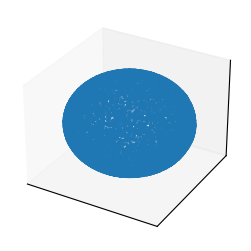

In [13]:
manifold = RadialManifold(dim=3, complexity=2)

theta=np.random.randn(20000,3)
theta/=np.linalg.norm(theta,axis=1,keepdims=True)

r=manifold.radius_batch(theta)
pts=theta*r[:,None]

fig=plt.figure(figsize=(4,3))
ax=fig.add_subplot(111,projection="3d")

ax.scatter(pts[:,0],pts[:,1],pts[:,2],s=1)

ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])

plt.show()

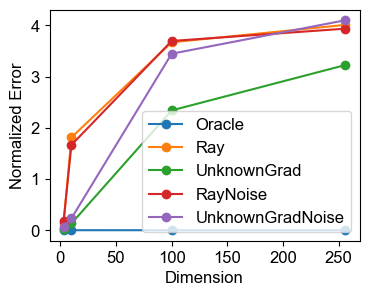

In [14]:
dims=[3,10,100,256]

methods={
"Oracle":method1,
"Ray":method2,
"UnknownGrad":method3,
"RayNoise":method4,
"UnknownGradNoise":method5
}

results={k:[] for k in methods}

for d in dims:

    manifold=RadialManifold(dim=d,complexity=2)
    targets=generate_targets(manifold,n=15,dist=0.3)

    gt=[ground_truth(manifold,t) for t in targets]

    for name,m in methods.items():

        errs=[]

        for t,g in zip(targets,gt):

            est=m(manifold,t)
            errs.append(normalized_error(est,g))

        results[name].append(np.mean(errs))


plt.figure(figsize=(4,3))

for k,v in results.items():
    plt.plot(dims,v,marker="o",label=k)

plt.xlabel("Dimension")
plt.ylabel("Normalized Error")
plt.legend()

plt.show()

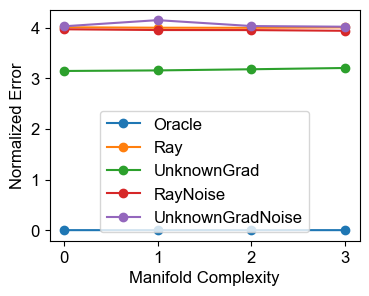

In [15]:
levels=[0,1,2,3]

manifold_dim=256

results={k:[] for k in methods}

for L in levels:

    manifold=RadialManifold(dim=manifold_dim,complexity=L)

    targets=generate_targets(manifold,n=20,dist=0.3)
    gt=[ground_truth(manifold,t) for t in targets]

    for name,m in methods.items():

        errs=[]

        for t,g in zip(targets,gt):

            est=m(manifold,t)
            errs.append(normalized_error(est,g))

        results[name].append(np.mean(errs))


plt.figure(figsize=(4,3))

for k,v in results.items():
    plt.plot(levels,v,marker="o",label=k)

plt.xlabel("Manifold Complexity")
plt.ylabel("Normalized Error")

plt.legend()
plt.show()

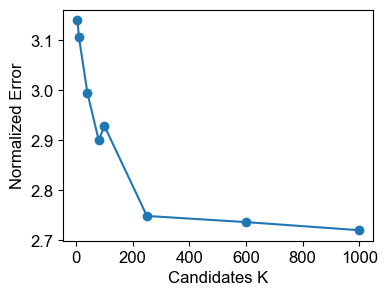

In [35]:
Kvals=[5,10,40,80,100,250,600,1000]

manifold=RadialManifold(dim=256,complexity=2)
targets=generate_targets(manifold,n=20,dist=0.4)
gt=[ground_truth(manifold,t) for t in targets]

errs=[]

for k in Kvals:

    e=[]

    for t,g in zip(targets,gt):

        est=method5(manifold,t,K=k)
        e.append(normalized_error(est,g))

    errs.append(np.mean(e))


plt.figure(figsize=(4,3))
plt.plot(Kvals,errs,marker="o")

plt.xlabel("Candidates K")
plt.ylabel("Normalized Error")

plt.show()

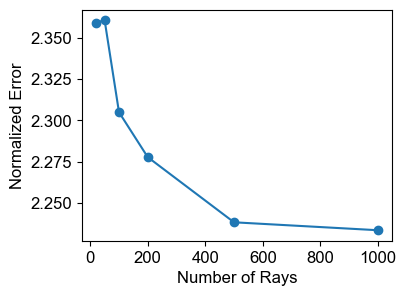

In [34]:
rays=[20,50,100,200,500,1000]

manifold=RadialManifold(dim=256,complexity=2)
targets=generate_targets(manifold,n=20,dist=0.5)
gt=[ground_truth(manifold,t) for t in targets]

errs=[]

for r in rays:

    e=[]

    for t,g in zip(targets,gt):

        est=method4(manifold,t,rays=r)
        e.append(normalized_error(est,g))

    errs.append(np.mean(e))


plt.figure(figsize=(4,3))
plt.plot(rays,errs,marker="o")

plt.xlabel("Number of Rays")
plt.ylabel("Normalized Error")

plt.show()

In [20]:
manifold=RadialManifold(dim=256,complexity=2)
targets=generate_targets(manifold,n=20,dist=0.3)

methods_runtime={
"Oracle":method1,
"Ray":method2,
"UnknownGrad":method3,
"RayNoise":method4,
"UnknownGradNoise":method5
}

for name,m in methods_runtime.items():

    start=time.time()

    for t in targets:
        m(manifold,t)

    print(name,"runtime:",round(time.time()-start,3),"seconds")

Oracle runtime: 0.039 seconds
Ray runtime: 0.061 seconds
UnknownGrad runtime: 0.291 seconds
RayNoise runtime: 0.06 seconds
UnknownGradNoise runtime: 0.337 seconds


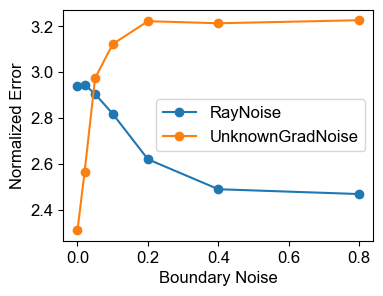

In [32]:
noise=[0,0.02,0.05,0.1,0.2, 0.4, 0.8]

# use larger distance so noise effects are realistic
target_dist=0.4

manifold=RadialManifold(dim=256,complexity=2)
targets=generate_targets(manifold,n=20,dist=target_dist)

gt=[ground_truth(manifold,t) for t in targets]

errs_m4=[]
errs_m5=[]

for n in noise:

    e4=[]
    e5=[]

    for t,g in zip(targets,gt):

        est4=method4(manifold,t,noise=n)
        est5=method5(manifold,t,noise=n)

        e4.append(normalized_error(est4,g))
        e5.append(normalized_error(est5,g))

    errs_m4.append(np.mean(e4))
    errs_m5.append(np.mean(e5))


plt.figure(figsize=(4,3))

plt.plot(noise,errs_m4,marker="o",label="RayNoise")
plt.plot(noise,errs_m5,marker="o",label="UnknownGradNoise")

plt.xlabel("Boundary Noise")
plt.ylabel("Normalized Error")

plt.legend()

plt.show()

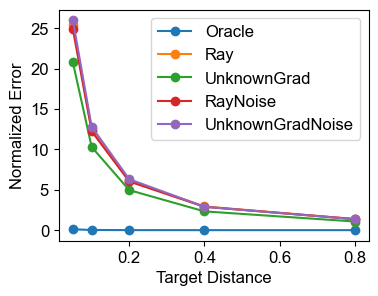

In [27]:
distances = [0.05,0.1,0.2,0.4,0.8]

manifold = RadialManifold(dim=256, complexity=2)

methods_all = {
    "Oracle": method1,
    "Ray": method2,
    "UnknownGrad": method3,
    "RayNoise": method4,
    "UnknownGradNoise": method5
}

results = {name: [] for name in methods_all}

for d in distances:

    targets = generate_targets(manifold, n=20, dist=d)
    gt = [ground_truth(manifold, t) for t in targets]

    for name, m in methods_all.items():
        errs = []

        for t, g in zip(targets, gt):
            est = m(manifold, t)
            errs.append(normalized_error(est, g))

        results[name].append(np.mean(errs))


plt.figure(figsize=(4,3))

for name, vals in results.items():
    plt.plot(distances, vals, marker="o", label=name)

plt.xlabel("Target Distance")
plt.ylabel("Normalized Error")
plt.legend()
plt.show()

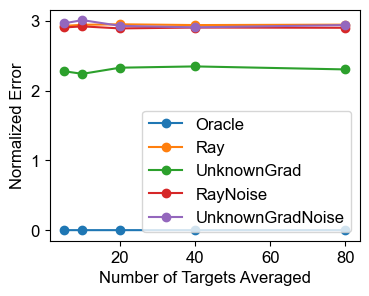

In [36]:
targets_avg = [5,10,20,40,80]

manifold = RadialManifold(dim=256, complexity=2)

# keep distance fixed
target_distance = 0.4

methods_all = {
    "Oracle": method1,
    "Ray": method2,
    "UnknownGrad": method3,
    "RayNoise": method4,
    "UnknownGradNoise": method5
}

results = {name: [] for name in methods_all}

for n_targets in targets_avg:

    targets = generate_targets(manifold, n=n_targets, dist=target_distance)
    gt = [ground_truth(manifold, t) for t in targets]

    for name, m in methods_all.items():

        errs = []

        for t, g in zip(targets, gt):
            est = m(manifold, t)
            errs.append(normalized_error(est, g))

        results[name].append(np.mean(errs))


plt.figure(figsize=(4,3))

for name, vals in results.items():
    plt.plot(targets_avg, vals, marker="o", label=name)

plt.xlabel("Number of Targets Averaged")
plt.ylabel("Normalized Error")

plt.legend()
plt.show()

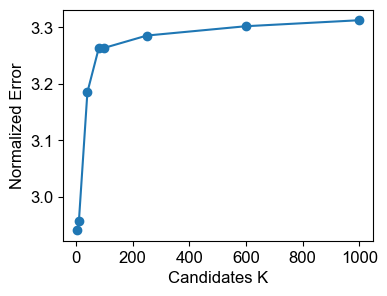

In [37]:
Kvals=[5,10,40,80,100,250,600,1000]

manifold=RadialManifold(dim=256,complexity=2)
targets=generate_targets(manifold,n=20,dist=0.4)
gt=[ground_truth(manifold,t) for t in targets]

errs=[]

base_step=0.25
Kref=10   # reference scale

for k in Kvals:

    step=base_step*np.sqrt(Kref/k)

    e=[]

    for t,g in zip(targets,gt):

        theta=random_unit(manifold.dim)

        for _ in range(20):

            cand=theta+step*random_unit(manifold.dim,k)
            cand/=np.linalg.norm(cand,axis=1,keepdims=True)

            r=manifold.radius_batch(cand)
            r+=np.random.normal(0,0.05,len(r))

            surf=cand*r[:,None]

            d=np.linalg.norm(surf-t,axis=1)

            theta=cand[np.argmin(d)]

        est=np.linalg.norm(manifold.surface(theta)-t)

        e.append(normalized_error(est,g))

    errs.append(np.mean(e))


plt.figure(figsize=(4,3))
plt.plot(Kvals,errs,marker="o")

plt.xlabel("Candidates K")
plt.ylabel("Normalized Error")

plt.show()

In [38]:
manifold = RadialManifold(dim=256, complexity=2)

targets = generate_targets(manifold, n=20, dist=0.4)

gt = [ground_truth(manifold, t) for t in targets]

methods_all = {
    "Oracle": method1,
    "Ray": method2,
    "UnknownGrad": method3,
    "RayNoise": method4,
    "UnknownGradNoise": method5
}

std_results = {}

for name, m in methods_all.items():

    errs = []

    for t, g in zip(targets, gt):

        est = m(manifold, t)
        errs.append(normalized_error(est, g))

    std_results[name] = np.std(errs)


for k, v in std_results.items():
    print(k, "std dev:", round(v,4))

Oracle std dev: 0.0
Ray std dev: 0.036
UnknownGrad std dev: 0.1037
RayNoise std dev: 0.0436
UnknownGradNoise std dev: 0.1597
